# Eval Results Dashboard
This notebook parses evaluation logs under `experiments/eval`, keeps only the most recent run for duplicated experiment settings, and shows per-dataset tables and charts.

In [ ]:
from __future__ import annotations

import ast
import re
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

    RUN_DIR_PATTERN = re.compile(
    r"way(?P<way>\d+)_shot(?P<shot>\d+)_bgclass(?P<bgclass>\d+)_(?P<timestamp>\d{8}_\d{6})"
)


def discover_eval_root(start_dir: Optional[Path] = None) -> Path:
    if start_dir is None:
        start_dir = Path.cwd()

    start_dir = start_dir.resolve()
    candidates = []

    for base in [start_dir, *start_dir.parents]:
        candidates.append(base / 'experiments' / 'eval')
        candidates.append(base / 'fs-cs' / 'experiments' / 'eval')

    for candidate in candidates:
        if candidate.exists() and candidate.is_dir():
            return candidate

    # Fallback for environments where paths are mounted later.
    return (start_dir / 'experiments' / 'eval').resolve()


EVAL_ROOT = discover_eval_root()
ROOT = EVAL_ROOT.parent.parent


def _extract_last_metrics_dict(text: str) -> Optional[Dict[str, Any]]:
    marker = 'DATALOADER:0 TEST RESULTS'
    marker_idx = text.rfind(marker)
    if marker_idx == -1:
        return None

    snippet = text[marker_idx:]
    start = snippet.find('{')
    if start == -1:
        return None

    depth = 0
    end = None
    for i in range(start, len(snippet)):
        char = snippet[i]
        if char == '{':
            depth += 1
        elif char == '}':
            depth -= 1
            if depth == 0:
                end = i + 1
                break

    if end is None:
        return None

    dict_str = snippet[start:end]
    parsed = ast.literal_eval(dict_str)
    if not isinstance(parsed, dict):
        return None

    return {str(k).strip(): v for k, v in parsed.items()}


def _extract_run_info_from_path(log_path: Path) -> Optional[Dict[str, Any]]:
    parts = log_path.resolve().parts
    eval_positions = [i for i, p in enumerate(parts) if p == 'eval']
    if not eval_positions:
        return None

    eval_idx = eval_positions[-1]
    # Need: eval / dataset / method / strategy / run_dir / eval.log
    if len(parts) <= eval_idx + 5:
        return None

    dataset = parts[eval_idx + 1]
    method = parts[eval_idx + 2]
    strategy = parts[eval_idx + 3]
    run_dir = parts[eval_idx + 4]
    filename = parts[eval_idx + 5]
    if filename != 'eval.log':
        return None

    match = RUN_DIR_PATTERN.search(run_dir)
    if not match:
        return None

    timestamp_raw = match.group('timestamp')
    timestamp_dt = datetime.strptime(timestamp_raw, '%Y%m%d_%H%M%S')

    return {
        'dataset': dataset,
        'method': method,
        'strategy': strategy,
        'way': int(match.group('way')),
        'shot': int(match.group('shot')),
        'bgclass': int(match.group('bgclass')),
        'run_timestamp': timestamp_raw,
        'timestamp_dt': timestamp_dt,
    }


def parse_eval_log(log_path: Path) -> Optional[Dict[str, Any]]:
    path_info = _extract_run_info_from_path(log_path)
    if not path_info:
        return None

    try:
        content = log_path.read_text(encoding='utf-8', errors='ignore')
        metrics = _extract_last_metrics_dict(content)
        if not metrics:
            return None

        row = {
            **path_info,
            'fold': int(metrics['fold']) if metrics.get('fold') is not None else np.nan,
            'miou': float(metrics['test/miou']) if metrics.get('test/miou') is not None else np.nan,
            'error_rate': float(metrics['test/error_rate']) if metrics.get('test/error_rate') is not None else np.nan,
            'er': float(metrics['test/er']) if metrics.get('test/er') is not None else np.nan,
            'f1_scores': metrics.get('test/F1-scores'),
            'precisions': metrics.get('test/Precisions'),
            'recalls': metrics.get('test/Recalls'),
            'log_path': str(log_path),
        }

        if isinstance(row['f1_scores'], list) and row['f1_scores']:
            row['f1_macro'] = float(np.mean(row['f1_scores']))
        else:
            row['f1_macro'] = np.nan

        if isinstance(row['precisions'], list) and row['precisions']:
            row['precision_macro'] = float(np.mean(row['precisions']))
        else:
            row['precision_macro'] = np.nan

        if isinstance(row['recalls'], list) and row['recalls']:
            row['recall_macro'] = float(np.mean(row['recalls']))
        else:
            row['recall_macro'] = np.nan

        return row
    except Exception:
        return None


def load_eval_results(eval_root: Path = EVAL_ROOT) -> pd.DataFrame:
    eval_root = eval_root.resolve()
    if not eval_root.exists():
        raise RuntimeError(f'Eval root does not exist: {eval_root}')

    log_paths = sorted(eval_root.rglob('eval.log'))
    rows = []
    skipped = []

    for log_path in log_paths:
        parsed = parse_eval_log(log_path)
        if parsed is None:
            skipped.append(str(log_path))
        else:
            rows.append(parsed)

    if not log_paths:
        raise RuntimeError(f'No eval.log files were found under: {eval_root}')

    if not rows:
        raise RuntimeError(
            f'Found {len(log_paths)} eval.log files under {eval_root}, but none could be parsed.'
        )

    df = pd.DataFrame(rows)
    df['miou'] = pd.to_numeric(df['miou'], errors='coerce')
    df['error_rate'] = pd.to_numeric(df['error_rate'], errors='coerce')
    df['fold'] = pd.to_numeric(df['fold'], errors='coerce')

    print(f'Eval root: {eval_root}')
    print(f'Parsed logs: {len(df)} / {len(log_paths)}')
    if skipped:
        print(f'Skipped logs (parse failed): {len(skipped)}')
        for path in skipped[:5]:
            print(f'  - {path}')
        if len(skipped) > 5:
            print('  - ...')

    return df


def select_latest_runs(df: pd.DataFrame) -> pd.DataFrame:
    # Duplicates are runs with same experiment setup; keep the newest timestamp.
    experiment_cols = ['dataset', 'method', 'strategy', 'way', 'shot', 'bgclass', 'fold']

    latest = (
        df.sort_values('timestamp_dt')
        .groupby(experiment_cols, dropna=False, as_index=False)
        .tail(1)
        .sort_values(['dataset', 'method', 'strategy', 'way', 'shot', 'bgclass', 'fold'])
        .reset_index(drop=True)
    )
    return latest


def plot_method_strategy_heatmap(ds: pd.DataFrame, dataset: str) -> None:
    pivot = (
        ds.groupby(['method', 'strategy'], as_index=False)['miou']
        .mean()
        .pivot(index='method', columns='strategy', values='miou')
        .sort_index()
    )
    if pivot.empty:
        return

    fig, ax = plt.subplots(figsize=(max(6, 1.5 * len(pivot.columns)), max(3.5, 0.8 * len(pivot.index))))
    values = pivot.values
    im = ax.imshow(values, cmap='viridis', aspect='auto')

    ax.set_title(f'{dataset}: Mean mIoU by Method x Strategy')
    ax.set_xlabel('Support Strategy')
    ax.set_ylabel('Method')
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            val = values[i, j]
            if pd.notna(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white', fontsize=9)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('mIoU')
    plt.tight_layout()
    plt.show()


def plot_best_per_method(ds: pd.DataFrame, dataset: str) -> None:
    if ds.empty:
        return

    idx = ds.groupby('method')['miou'].idxmax()
    best = ds.loc[idx].sort_values('miou', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(best)), 4))
    bars = ax.bar(best['method'], best['miou'])
    ax.set_title(f'{dataset}: Best mIoU per Method (latest runs)')
    ax.set_ylabel('mIoU')
    ax.set_xlabel('Method')
    ax.grid(axis='y', alpha=0.25)

    for bar, val in zip(bars, best['miou']):
        ax.text(bar.get_x() + bar.get_width() / 2, val, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_shot_trend(ds: pd.DataFrame, dataset: str) -> None:
    shot_curve = ds.groupby(['shot', 'method'], as_index=False)['miou'].mean().sort_values(['method', 'shot'])
    if shot_curve.empty or shot_curve['shot'].nunique() < 2:
        return

    fig, ax = plt.subplots(figsize=(7, 4))
    for method, grp in shot_curve.groupby('method'):
        x = grp['shot'].to_numpy()
        y = grp['miou'].to_numpy()
        ax.plot(x, y, marker='o', linewidth=2, label=method)

    ax.set_title(f'{dataset}: Mean mIoU by Shot')
    ax.set_xlabel('Shot')
    ax.set_ylabel('Mean mIoU')
    ax.grid(alpha=0.25)
    ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [6]:
df_all = load_eval_results(EVAL_ROOT)
df_latest = select_latest_runs(df_all)

display(Markdown('## Global Summary'))
summary = (
    df_latest.groupby('dataset', as_index=False)
    .agg(
        latest_runs=('dataset', 'size'),
        methods=('method', 'nunique'),
        strategies=('strategy', 'nunique'),
        shots=('shot', lambda s: sorted(s.unique().tolist())),
        bgclasses=('bgclass', lambda s: sorted(s.unique().tolist())),
    )
    .sort_values('dataset')
)
display(summary)

display(Markdown('### Latest-Only Runs (all datasets)'))
display(
    df_latest[
        [
            'dataset', 'method', 'strategy', 'way', 'shot', 'bgclass', 'fold',
            'miou', 'error_rate', 'f1_macro', 'precision_macro', 'recall_macro',
            'run_timestamp', 'log_path',
        ]
    ].sort_values(['dataset', 'miou'], ascending=[True, False]).reset_index(drop=True)
)

Eval root: /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval
Parsed logs: 208 / 210
Skipped logs (parse failed): 2
  - /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval/chesapeake/asnet/random/way5_shot1_bgclass3_20260414_132939/eval.log
  - /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval/chesapeake/pfenet/random/way5_shot1_bgclass2_20260414_011314/eval.log


## Global Summary

,dataset,latest_runs,methods,strategies,shots,bgclasses
0,chesapeake,120,4,3,"[1, 5]","[0, 2, 3]"
1,oem,24,4,3,"[1, 5]",[0]


### Latest-Only Runs (all datasets)

,dataset,method,strategy,way,shot,bgclass,fold,miou,error_rate,f1_macro,precision_macro,recall_macro,run_timestamp,log_path
0,chesapeake,panet,similarity,5,5,3,0,32.423653,62.599998,0.717228,0.755644,0.703993,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
1,chesapeake,panet,random,5,5,3,0,32.124969,62.099998,0.712785,0.748194,0.700370,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
2,chesapeake,panet,random,6,5,0,0,30.654188,69.300003,0.578615,0.669492,0.509953,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
3,chesapeake,panet,similarity,6,5,0,0,30.102310,74.199997,0.571555,0.668123,0.499956,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
4,chesapeake,panet,random,1,5,3,0,30.041307,4.699997,0.878432,0.873960,0.887145,20260414_142236,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,oem,pfenet,similarity,4,1,0,0,1.264144,100.000000,0.193536,0.196775,0.199669,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
140,oem,pfenet,random,4,1,0,0,1.045901,99.599998,0.185194,0.187739,0.191358,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
141,oem,pfenet,random,4,5,0,0,0.682923,99.900002,0.177696,0.176437,0.183623,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
142,oem,pfenet,max_area,4,5,0,0,0.468880,100.000000,0.172425,0.170196,0.178246,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...


## Dataset: chesapeake

- Latest runs: **120**

### Detailed table (sorted by mIoU desc)

,method,strategy,way,shot,bgclass,fold,miou,error_rate,f1_macro,precision_macro,recall_macro,run_timestamp,log_path
0,panet,similarity,5,5,3,0,32.423653,62.599998,0.717228,0.755644,0.703993,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
1,panet,random,5,5,3,0,32.124969,62.099998,0.712785,0.748194,0.700370,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
2,panet,random,6,5,0,0,30.654188,69.300003,0.578615,0.669492,0.509953,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
3,panet,similarity,6,5,0,0,30.102310,74.199997,0.571555,0.668123,0.499956,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
4,panet,random,1,5,3,0,30.041307,4.699997,0.878432,0.873960,0.887145,20260414_142236,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,pfenet,max_area,5,5,3,0,1.369416,83.699997,0.094111,0.262075,0.159026,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
116,pfenet,max_area,5,5,2,0,1.326644,85.900002,0.127347,0.275365,0.185301,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
117,pfenet,random,5,5,3,0,1.302195,89.199997,0.083045,0.254012,0.156822,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
118,pfenet,random,6,5,0,0,1.245475,91.500000,0.038480,0.259289,0.020822,20260414_205526,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...


### Aggregated table (mean mIoU by Method x Strategy)

,method,strategy,runs,miou_mean,miou_std
0,panet,similarity,10,27.481569,2.795734
1,panet,max_area,10,25.398787,3.907419
2,panet,random,10,24.572551,6.106863
3,hsnet,similarity,10,22.070137,2.920756
4,hsnet,max_area,10,21.137924,3.711398
5,hsnet,random,10,16.817031,4.423939
6,asnet,random,10,16.754352,3.087097
7,asnet,similarity,10,15.238567,3.449810
8,asnet,max_area,10,10.029006,2.744034
9,pfenet,similarity,10,4.563798,4.543516


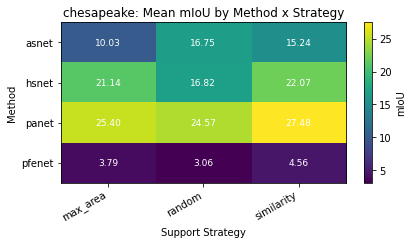

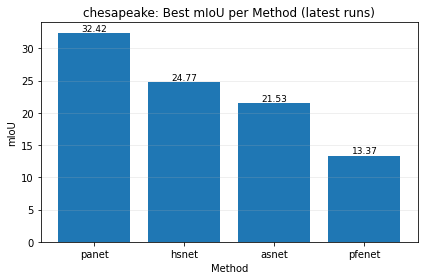

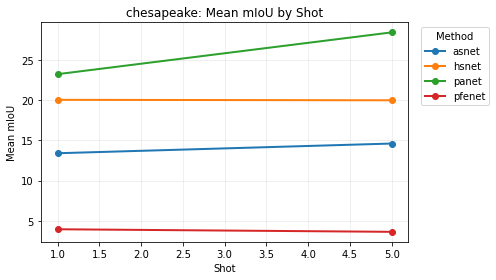

## Dataset: oem

- Latest runs: **24**

### Detailed table (sorted by mIoU desc)

,method,strategy,way,shot,bgclass,fold,miou,error_rate,f1_macro,precision_macro,recall_macro,run_timestamp,log_path
0,panet,max_area,4,5,0,0,27.470255,64.699997,0.491584,0.461007,0.573945,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
1,panet,random,4,5,0,0,27.093590,71.300003,0.502608,0.466382,0.594864,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
2,panet,similarity,4,5,0,0,24.940958,58.799999,0.477981,0.444503,0.558183,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
3,asnet,random,4,1,0,0,19.792933,87.000000,0.269829,0.322204,0.262202,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
4,panet,max_area,4,1,0,0,19.624584,70.599998,0.392835,0.424410,0.381185,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
5,asnet,max_area,4,1,0,0,18.870100,88.199997,0.246598,0.277634,0.247946,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
6,asnet,similarity,4,5,0,0,16.086174,82.300003,0.263560,0.356423,0.257507,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
7,panet,random,4,1,0,0,15.712825,81.900002,0.352754,0.387894,0.340020,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
8,asnet,similarity,4,1,0,0,15.246299,88.199997,0.207967,0.255364,0.213719,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...
9,asnet,random,4,5,0,0,14.052732,85.599998,0.213815,0.267921,0.217844,20260413_005331,/home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experi...


### Aggregated table (mean mIoU by Method x Strategy)

,method,strategy,runs,miou_mean,miou_std
0,panet,max_area,2,23.547420,5.547727
1,panet,random,2,21.403207,8.047416
2,asnet,random,2,16.922832,4.058934
3,panet,similarity,2,16.858278,11.430636
4,asnet,max_area,2,16.393164,3.502916
5,asnet,similarity,2,15.666236,0.593881
6,hsnet,random,2,3.312775,1.712409
7,hsnet,max_area,2,2.447942,0.605692
8,hsnet,similarity,2,2.305958,0.194256
9,pfenet,similarity,2,1.332305,0.096394


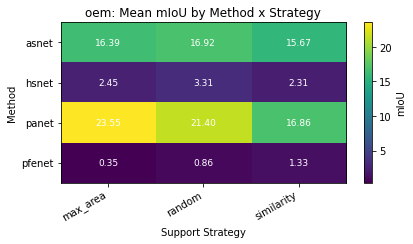

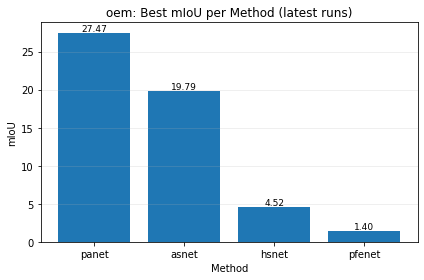

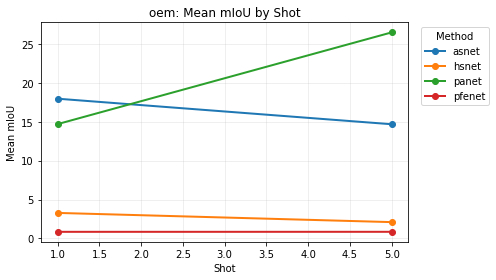

In [10]:
datasets = sorted(df_latest['dataset'].unique())

for dataset in datasets:
    ds = df_latest[df_latest['dataset'] == dataset].copy()

    display(Markdown(f'## Dataset: {dataset}'))
    display(Markdown(f'- Latest runs: **{len(ds)}**'))

    display(Markdown('### Detailed table (sorted by mIoU desc)'))
    detailed_cols = [
        'method', 'strategy', 'way', 'shot', 'bgclass', 'fold',
        'miou', 'error_rate', 'f1_macro', 'precision_macro', 'recall_macro',
        'run_timestamp', 'log_path',
    ]
    display(ds[detailed_cols].sort_values('miou', ascending=False).reset_index(drop=True))

    display(Markdown('### Aggregated table (mean mIoU by Method x Strategy)'))
    agg = (
        ds.groupby(['method', 'strategy'], as_index=False)
        .agg(
            runs=('miou', 'size'),
            miou_mean=('miou', 'mean'),
            miou_std=('miou', 'std'),
        )
        .sort_values('miou_mean', ascending=False)
        .reset_index(drop=True)
    )
    display(agg)

    plot_method_strategy_heatmap(ds, dataset)
    plot_best_per_method(ds, dataset)
    plot_shot_trend(ds, dataset)

In [11]:
out_dir = EVAL_ROOT / '_summaries'
out_dir.mkdir(parents=True, exist_ok=True)

all_path = out_dir / 'eval_results_all_parsed.csv'
latest_path = out_dir / 'eval_results_latest_only.csv'

df_all.sort_values('timestamp_dt').to_csv(all_path, index=False)
df_latest.sort_values(['dataset', 'method', 'strategy', 'way', 'shot', 'bgclass']).to_csv(latest_path, index=False)

print(f'Saved: {all_path}')
print(f'Saved: {latest_path}')

Saved: /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval/_summaries/eval_results_all_parsed.csv
Saved: /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval/_summaries/eval_results_latest_only.csv


## F1 Score Analysis
This section analyzes F1 in two ways:
- Per-class F1 (from `test/F1-scores`).
- Macro F1 (mean over class F1 scores).
It uses latest-only runs (`df_latest`) so duplicated experiments keep the most recent run only.

In [12]:
if 'df_latest' not in globals():
    df_all = load_eval_results(EVAL_ROOT)
    df_latest = select_latest_runs(df_all)


def build_f1_long(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in df.iterrows():
        scores = row.get('f1_scores')
        if not isinstance(scores, list):
            continue
        for class_idx, score in enumerate(scores):
            if score is None:
                continue
            rows.append(
                {
                    'dataset': row['dataset'],
                    'method': row['method'],
                    'strategy': row['strategy'],
                    'way': row['way'],
                    'shot': row['shot'],
                    'bgclass': row['bgclass'],
                    'fold': row['fold'],
                    'run_timestamp': row['run_timestamp'],
                    'class_idx': int(class_idx),
                    'f1': float(score),
                    'f1_macro': float(row['f1_macro']) if pd.notna(row['f1_macro']) else np.nan,
                }
            )
    return pd.DataFrame(rows)


f1_long = build_f1_long(df_latest)
if f1_long.empty:
    raise RuntimeError('No per-class F1 scores available in parsed logs.')

display(Markdown('### Macro F1 Summary (latest runs)'))
macro_summary = (
    df_latest.groupby(['dataset', 'method', 'strategy'], as_index=False)
    .agg(
        runs=('f1_macro', 'size'),
        macro_f1_mean=('f1_macro', 'mean'),
        macro_f1_std=('f1_macro', 'std'),
        macro_f1_max=('f1_macro', 'max'),
    )
    .sort_values(['dataset', 'macro_f1_mean'], ascending=[True, False])
    .reset_index(drop=True)
    .round(4)
    )
display(macro_summary)

display(Markdown('### Per-Class F1 Summary (latest runs)'))
per_class_summary = (
    f1_long.groupby(['dataset', 'method', 'strategy', 'class_idx'], as_index=False)
    .agg(
        runs=('f1', 'size'),
        f1_mean=('f1', 'mean'),
        f1_std=('f1', 'std'),
        f1_min=('f1', 'min'),
        f1_max=('f1', 'max'),
    )
    .sort_values(['dataset', 'f1_mean'], ascending=[True, False])
    .reset_index(drop=True)
    .round(4)
    )
display(per_class_summary)

### Macro F1 Summary (latest runs)

,dataset,method,strategy,runs,macro_f1_mean,macro_f1_std,macro_f1_max
0,chesapeake,panet,similarity,10,0.6929,0.1028,0.8413
1,chesapeake,panet,random,10,0.6425,0.1529,0.8784
2,chesapeake,hsnet,similarity,10,0.6230,0.1123,0.7621
3,chesapeake,hsnet,max_area,10,0.6194,0.1117,0.7548
4,chesapeake,panet,max_area,10,0.6121,0.1576,0.8242
5,chesapeake,hsnet,random,10,0.4949,0.1397,0.6942
6,chesapeake,asnet,random,10,0.4718,0.1233,0.6775
7,chesapeake,asnet,similarity,10,0.4476,0.1327,0.6633
8,chesapeake,asnet,max_area,10,0.3402,0.1097,0.5278
9,chesapeake,pfenet,similarity,10,0.2439,0.2323,0.6703


### Per-Class F1 Summary (latest runs)

,dataset,method,strategy,class_idx,runs,f1_mean,f1_std,f1_min,f1_max
0,chesapeake,panet,similarity,1,10,0.8456,0.0176,0.8162,0.8721
1,chesapeake,panet,max_area,1,10,0.8175,0.0372,0.7597,0.8617
2,chesapeake,panet,similarity,2,8,0.7891,0.0268,0.7444,0.8274
3,chesapeake,panet,max_area,2,8,0.7765,0.0353,0.7207,0.8280
4,chesapeake,panet,random,1,10,0.7703,0.1100,0.6312,0.9001
...,...,...,...,...,...,...,...,...,...
139,oem,pfenet,max_area,3,2,0.0079,0.0067,0.0031,0.0126
140,oem,hsnet,random,4,2,0.0068,0.0005,0.0065,0.0072
141,oem,hsnet,similarity,4,2,0.0067,0.0003,0.0065,0.0070
142,oem,hsnet,max_area,4,2,0.0059,0.0005,0.0056,0.0063


## F1 Details: chesapeake

### Macro-F1 by Method x Strategy

,method,strategy,runs,macro_f1_mean,macro_f1_std
8,panet,similarity,10,0.6929,0.1028
7,panet,random,10,0.6425,0.1529
5,hsnet,similarity,10,0.6230,0.1123
3,hsnet,max_area,10,0.6194,0.1117
6,panet,max_area,10,0.6121,0.1576
4,hsnet,random,10,0.4949,0.1397
1,asnet,random,10,0.4718,0.1233
2,asnet,similarity,10,0.4476,0.1327
0,asnet,max_area,10,0.3402,0.1097
11,pfenet,similarity,10,0.2439,0.2323


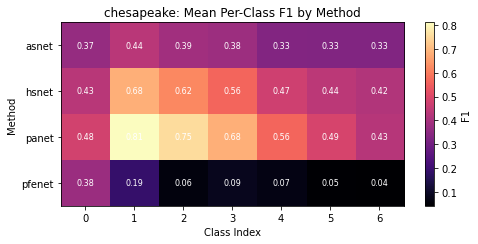

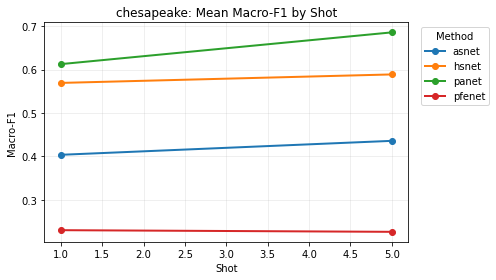

## F1 Details: oem

### Macro-F1 by Method x Strategy

,method,strategy,runs,macro_f1_mean,macro_f1_std
6,panet,max_area,2,0.4422,0.0698
7,panet,random,2,0.4277,0.1060
8,panet,similarity,2,0.3674,0.1565
1,asnet,random,2,0.2418,0.0396
2,asnet,similarity,2,0.2358,0.0393
0,asnet,max_area,2,0.2334,0.0187
4,hsnet,random,2,0.2140,0.0148
5,hsnet,similarity,2,0.2048,0.0011
3,hsnet,max_area,2,0.2008,0.0028
11,pfenet,similarity,2,0.1939,0.0005


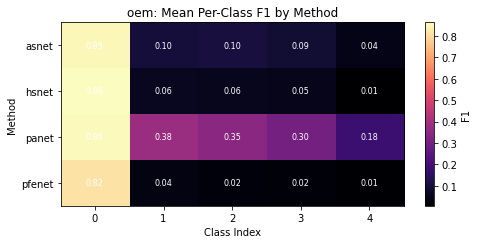

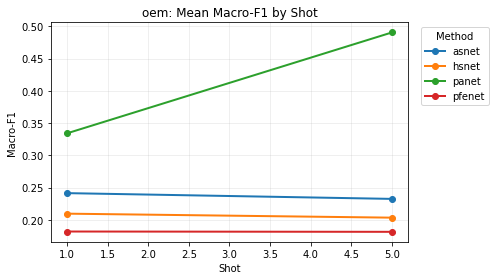

In [13]:
for dataset in sorted(df_latest['dataset'].unique()):
    ds_macro = df_latest[df_latest['dataset'] == dataset].copy()
    ds_class = f1_long[f1_long['dataset'] == dataset].copy()

    display(Markdown(f'## F1 Details: {dataset}'))

    # 1) Macro-F1 table by method x strategy
    macro_table = (
        ds_macro.groupby(['method', 'strategy'], as_index=False)
        .agg(
            runs=('f1_macro', 'size'),
            macro_f1_mean=('f1_macro', 'mean'),
            macro_f1_std=('f1_macro', 'std'),
        )
        .sort_values('macro_f1_mean', ascending=False)
        .round(4)
    )
    display(Markdown('### Macro-F1 by Method x Strategy'))
    display(macro_table)

    # 2) Per-class mean F1 heatmap by method
    class_heat = (
        ds_class.groupby(['method', 'class_idx'], as_index=False)['f1']
        .mean()
        .pivot(index='method', columns='class_idx', values='f1')
        .sort_index()
    )

    if not class_heat.empty:
        fig, ax = plt.subplots(figsize=(max(7, 0.9 * class_heat.shape[1]), max(3.5, 0.8 * class_heat.shape[0])))
        vals = class_heat.values
        im = ax.imshow(vals, cmap='magma', aspect='auto')
        ax.set_title(f'{dataset}: Mean Per-Class F1 by Method')
        ax.set_xlabel('Class Index')
        ax.set_ylabel('Method')
        ax.set_xticks(np.arange(len(class_heat.columns)))
        ax.set_xticklabels([str(c) for c in class_heat.columns])
        ax.set_yticks(np.arange(len(class_heat.index)))
        ax.set_yticklabels(class_heat.index)

        for i in range(vals.shape[0]):
            for j in range(vals.shape[1]):
                v = vals[i, j]
                if pd.notna(v):
                    ax.text(j, i, f'{v:.2f}', ha='center', va='center', color='white', fontsize=8)

        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('F1')
        plt.tight_layout()
        plt.show()

    # 3) Macro-F1 trend by shot per method
    shot_macro = (
        ds_macro.groupby(['shot', 'method'], as_index=False)['f1_macro']
        .mean()
        .sort_values(['method', 'shot'])
    )
    if not shot_macro.empty and shot_macro['shot'].nunique() >= 2:
        fig, ax = plt.subplots(figsize=(7, 4))
        for method, grp in shot_macro.groupby('method'):
            ax.plot(grp['shot'].to_numpy(), grp['f1_macro'].to_numpy(), marker='o', linewidth=2, label=method)
        ax.set_title(f'{dataset}: Mean Macro-F1 by Shot')
        ax.set_xlabel('Shot')
        ax.set_ylabel('Macro-F1')
        ax.grid(alpha=0.25)
        ax.legend(title='Method', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

In [14]:
# Optional exports for F1 analysis
out_dir = EVAL_ROOT / '_summaries'
out_dir.mkdir(parents=True, exist_ok=True)

f1_long_path = out_dir / 'f1_per_class_long_latest_only.csv'
f1_class_summary_path = out_dir / 'f1_per_class_summary_latest_only.csv'
f1_macro_summary_path = out_dir / 'f1_macro_summary_latest_only.csv'

f1_long.to_csv(f1_long_path, index=False)
per_class_summary.to_csv(f1_class_summary_path, index=False)
macro_summary.to_csv(f1_macro_summary_path, index=False)

print(f'Saved: {f1_long_path}')
print(f'Saved: {f1_class_summary_path}')
print(f'Saved: {f1_macro_summary_path}')

Saved: /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval/_summaries/f1_per_class_long_latest_only.csv
Saved: /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval/_summaries/f1_per_class_summary_latest_only.csv
Saved: /home/matheuspimenta/Jobs/SR/ifsl/fs-cs/experiments/eval/_summaries/f1_macro_summary_latest_only.csv
